In [50]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [51]:
train_data = pd.read_csv("../tmp/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [52]:
test_data = pd.read_csv("../tmp/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [53]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

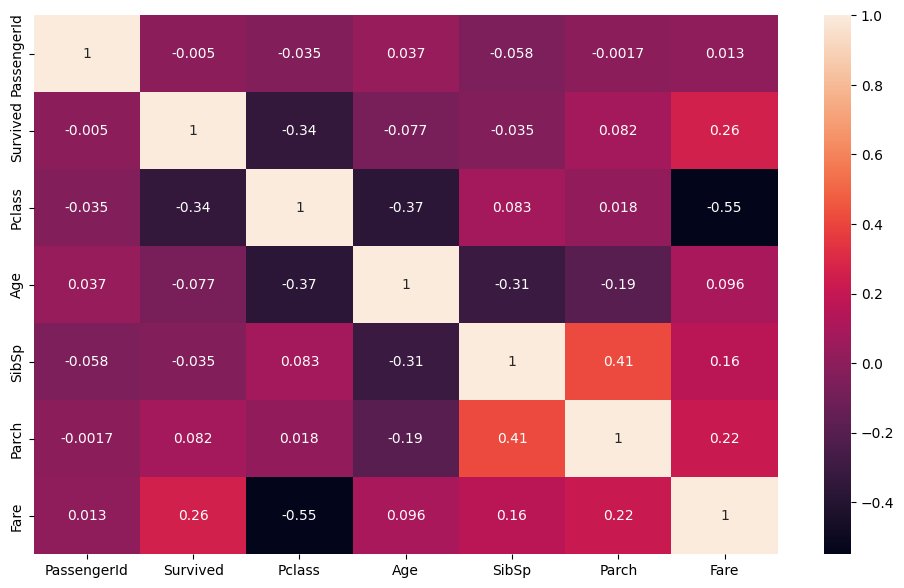

In [54]:
plt.figure(figsize=(12,7))
sns.heatmap(train_data.select_dtypes(include = ['number']).corr(), annot=True,)
plt.show()

# Version 3: Thay đổi việc xử lý missing value


<h1>Nhận xét thấy Age tương quan vừa với Pclass
-> Ta sẽ dùng IterativeImputer với X = Pclass, y là Age</h1>


In [55]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.linear_model import BayesianRidge
# imp = IterativeImputer(max_iter=10, random_state=0)

# --- BƯỚC 1: LỌC CÁC CỘT CẦN DÙNG ĐỂ IMUPUTE ---
# Ta chỉ cần 'Age' (cột có thiếu) và 'Pclass' (cột để dự đoán)
# Pclass cần được chuyển thành kiểu số nguyên nếu chưa phải
X_impute = train_data[['Age', 'Pclass']].copy()

# --- BƯỚC 2: KHỞI TẠO VÀ CẤU HÌNH IMputer ---
# Sử dụng BayesianRidge làm estimator thường tốt hơn LinearRegression mặc định
# Bạn có thể giữ mặc định nếu muốn, nhưng đây là một tùy chọn nâng cao.
estimator = BayesianRidge()
# imputer_age = IterativeImputer(
#     estimator=estimator,
#     max_iter=10, 
#     random_state=42 # Đặt random_state để đảm bảo kết quả có thể tái lập
# )
imputer_age = KNNImputer(
    n_neighbors=5,  
    weights='uniform' 
)

# --- BƯỚC 3: FIT VÀ TRANSFORM DỮ LIỆU ---
# Fit: huấn luyện mô hình dự đoán trên dữ liệu có sẵn
# Transform: áp dụng mô hình để điền khuyết các giá trị NaN
X_imputed_array = imputer_age.fit_transform(X_impute)

# --- BƯỚC 4: CẬP NHẬT DATAFRAME GỐC ---
# Lấy cột Age đã được điền khuyết (cột đầu tiên của mảng kết quả)
train_data['Age_Imputed'] = X_imputed_array[:, 0]

# Chuyển đổi Age_Imputed sang số nguyên nếu bạn muốn tuổi là số nguyên
train_data['Age_Imputed'] = train_data['Age_Imputed'].round().astype(int)

# In kết quả
print("\nDataFrame sau khi điền khuyết:")
print(train_data[['Age', 'Pclass', 'Age_Imputed']].sample(5))


DataFrame sau khi điền khuyết:
      Age  Pclass  Age_Imputed
608  22.0       2           22
549   8.0       2            8
788   1.0       3            1
688  18.0       3           18
720   6.0       2            6


In [56]:
# train_data.drop(columns = ['Age'], inplace=True)

<h1>Xử lý missing value Embarked dễ dàng vì chỉ có vài dòng bị mất</h1>


In [57]:
# Gán giá trị mode (giá trị xuất hiện nhiều nhất) cho các giá trị missing của cột "Embarked" 
most_common_embarked = train_data['Embarked'].mode()[0]
train_data['Embarked'] = train_data['Embarked'].fillna(most_common_embarked)

<h1>Kiểm tra hết missing value chưa</h1>


In [58]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Imputed      0
dtype: int64

<h1>Xử lý Cabin


In [59]:
# train_data["CabinKnown"] = train_data["Cabin"].notnull().astype(int)
# test_data["CabinKnown"] = test_data["Cabin"].notnull().astype(int)

In [60]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Imputed      0
dtype: int64

<h1>Kiểm tra missing value bên tập test</h1>


In [61]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<h1>Xử lý missing Age</h1>


In [62]:
X_impute = test_data[['Age', 'Pclass']].copy()
X_imputed_array = imputer_age.transform(X_impute)
test_data['Age_Imputed'] = X_imputed_array[:, 0]
test_data['Age_Imputed'] = test_data['Age_Imputed'].round().astype(int)

<h1>Xử lý missing fare dễ dàng vì chỉ mất 1 hàng</h1>


In [63]:
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())

<h1>Kiểm tra còn missing value không


In [64]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
Age_Imputed      0
dtype: int64

In [65]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
Age_Imputed      0
dtype: int64

In [66]:
print(train_data.isna().sum().sum())
print(test_data.isna().sum().sum())

864
413


<h1>Drop cột ticket


<h1>Xử lý name cho 2 tập bằng cách cắt ra từ đầu tiên sau dấu phẩy (Mr, Mrs, Dr,..)


In [67]:
# 1. Tạo name_title từ Name (làm trước khi drop)
train_data['name_title'] = train_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())
test_data['name_title'] = test_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())

# 2. Lấy top 5 title phổ biến nhất
top_5_titles = train_data['name_title'].value_counts().head(5).index.tolist()
print("Top 5 titles:", top_5_titles)

# 3. Gom tất cả title khác thành "Other"
train_data['name_title'] = train_data['name_title'].apply(lambda x: x if x in top_5_titles else 'Other')
test_data['name_title'] = test_data['name_title'].apply(lambda x: x if x in top_5_titles else 'Other')

# 4. Kiểm tra kết quả - CHỈ CÒN 6 CATEGORIES
print("\nAfter grouping - chỉ còn 6 categories:")
print(train_data['name_title'].value_counts())
print("\nTest data name_title counts:")
print(test_data['name_title'].value_counts())

# train_data['name_title'] = train_data['name_title'].map({'Mr':0, 'Miss':1, 'Mrs':2, 'Master':3, 'Dr':5, 'Other': 6})
# test_data['name_title'] = test_data['name_title'].map({'Mr':0, 'Miss':1, 'Mrs':2, 'Master':3, 'Dr':5, 'Other': 6})

# # 5. Sau đó mới drop column Name



Top 5 titles: ['Mr', 'Miss', 'Mrs', 'Master', 'Dr']

After grouping - chỉ còn 6 categories:
name_title
Mr        517
Miss      182
Mrs       125
Master     40
Other      20
Dr          7
Name: count, dtype: int64

Test data name_title counts:
name_title
Mr        240
Miss       78
Mrs        72
Master     21
Other       6
Dr          1
Name: count, dtype: int64


<h1>BoyOrFemale


In [68]:
def is_boy_row(row):
    # "boy" = male & (Age < 16 OR Title == 'Master')
    # age may be missing; Title helps
    return (row["Sex"] == "male") and ( (pd.notna(row["Age"]) and row["Age"] < 16) or (row.get("name_title","") == "Master"))

train_data["Boy"] = train_data.apply(is_boy_row, axis=1)
train_data["WomanOrBoy"] = (train_data["Sex"] == "female") | (train_data["Boy"])
test_data["Boy"] = test_data.apply(is_boy_row, axis=1)
test_data["WomanOrBoy"] = (test_data["Sex"] == "female") | (test_data["Boy"])

<h1>Mã hóa cột Sex thành 0 - 1


In [69]:
# Map male - 0, fale - 1
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

In [70]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Imputed      0
name_title       0
Boy              0
WomanOrBoy       0
dtype: int64

In [71]:
train_data['Embarked'].value_counts

<bound method IndexOpsMixin.value_counts of 0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object>

In [72]:
pd.crosstab(index=train_data['Embarked'], columns=train_data['Survived'])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,219


In [73]:
train_data['Embarked'] = train_data['Embarked'].map({'C': 1, 'Q': 2, 'S': 3})
test_data['Embarked'] = test_data['Embarked'].map({'C': 1, 'Q': 2, 'S': 3})

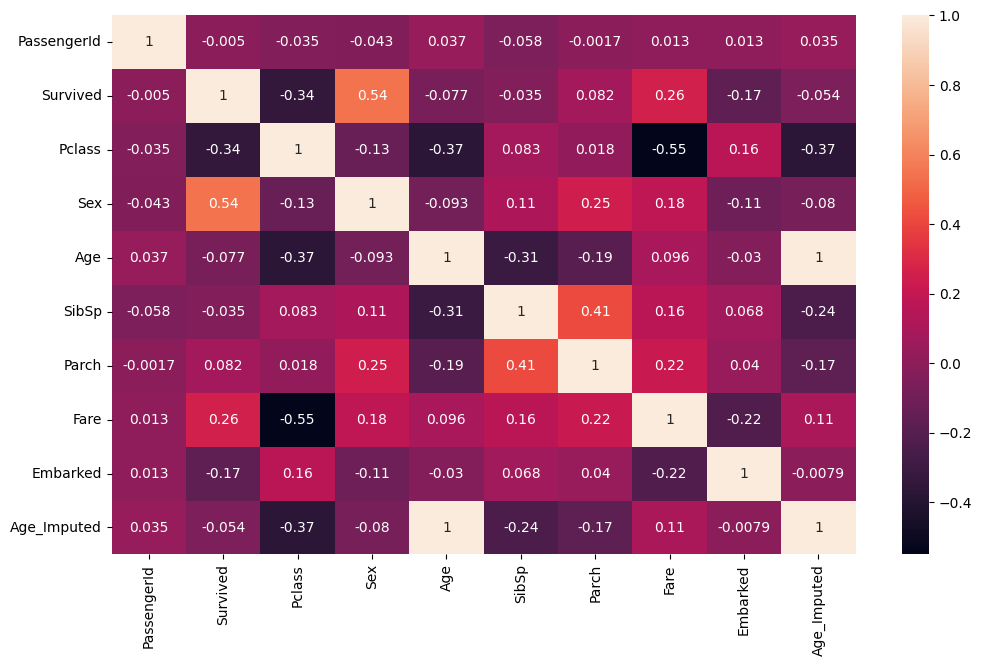

In [74]:
plt.figure(figsize=(12,7))
sns.heatmap(train_data.select_dtypes(include = ['number']).corr(), annot=True,)
plt.show()

In [75]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Imputed      0
name_title       0
Boy              0
WomanOrBoy       0
dtype: int64

In [76]:
# train_data['Fare'] = np.log1p(train_data['Fare'].clip(lower=0))
# test_data['Fare'] = np.log1p(test_data['Fare'].clip(lower=0))

In [77]:
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1
train_data["FarePerPerson"] = (train_data["Fare"] / train_data["FamilySize"])
test_data["FarePerPerson"] = (test_data["Fare"] / test_data["FamilySize"])

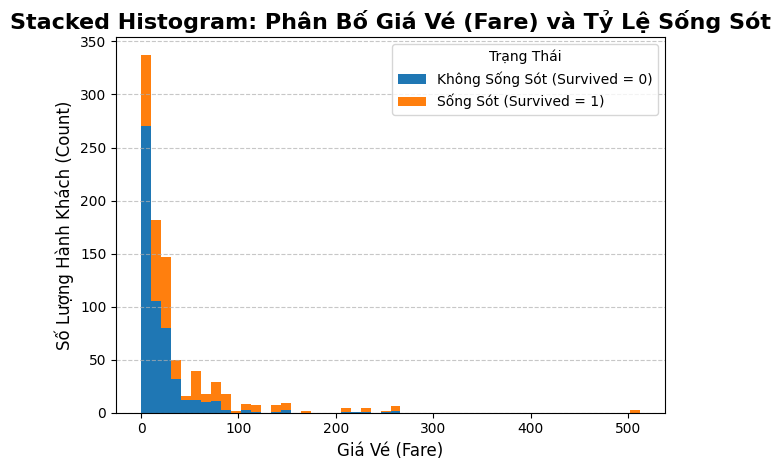

In [78]:
pd.crosstab(index=train_data['Fare'], columns = train_data['Survived'])
x_data1 = train_data[train_data['Survived'] == 0]['Fare']
x_data2 = train_data[train_data['Survived'] == 1]['Fare']
x_data = [x_data1, x_data2]
labels = ['Không Sống Sót (Survived = 0)', 'Sống Sót (Survived = 1)']
plt.hist(x_data, bins = 50, stacked=True, label=labels)
plt.title('Stacked Histogram: Phân Bố Giá Vé (Fare) và Tỷ Lệ Sống Sót', fontsize=16, fontweight='bold')
plt.xlabel('Giá Vé (Fare)', fontsize=12)
plt.ylabel('Số Lượng Hành Khách (Count)', fontsize=12)
plt.legend(loc='upper right', title="Trạng Thái")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [79]:
train_data['Fare'].value_counts

<bound method IndexOpsMixin.value_counts of 0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64>

In [80]:
# Cắt các giá trị theo khoảng và gắn labels
train_data['Fare_Cat'] = pd.cut(train_data['Fare'], bins=[-1000,40,80,200,1000], labels=['so_cheap', 'cheap', 'Medium', 'Expensive'])
test_data['Fare_Cat'] = pd.cut(test_data['Fare'], bins=[-1000,40,80,200,1000], labels=['so_cheap', 'cheap', 'Medium', 'Expensive']) 

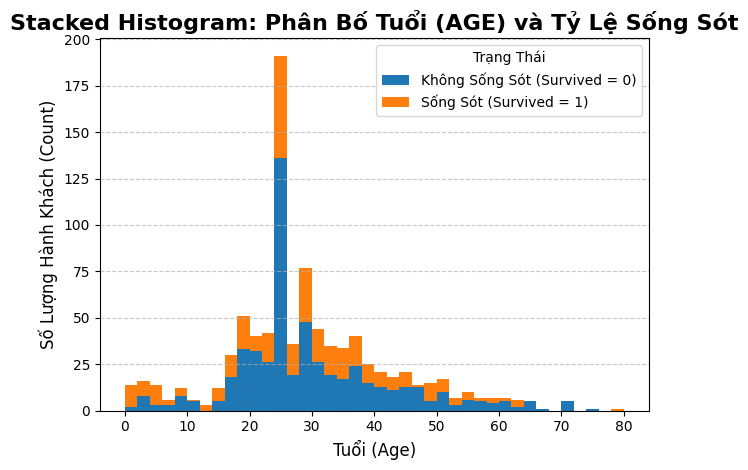

In [81]:
pd.crosstab(index=train_data['Age_Imputed'], columns = train_data['Survived'])
x_data1 = train_data[train_data['Survived'] == 0]['Age_Imputed']
x_data2 = train_data[train_data['Survived'] == 1]['Age_Imputed']
x_data = [x_data1, x_data2]
labels = ['Không Sống Sót (Survived = 0)', 'Sống Sót (Survived = 1)']
plt.hist(x_data, bins = 40, stacked=True, label=labels)
plt.title('Stacked Histogram: Phân Bố Tuổi (AGE) và Tỷ Lệ Sống Sót', fontsize=16, fontweight='bold')
plt.xlabel('Tuổi (Age)', fontsize=12)
plt.ylabel('Số Lượng Hành Khách (Count)', fontsize=12)
plt.legend(loc='upper right', title="Trạng Thái")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

0-12
12-22
22-34
34-46
46-64
64-100


In [82]:
# Cắt các giá trị theo khoảng và gắn labels
train_data['Age_Cat'] = pd.cut(train_data['Age_Imputed'], bins=[-100,12,22,34,46,64,100], labels=['babi', 'so_young', 'young', 'teenager', 'adult', 'old'])
test_data['Age_Cat'] = pd.cut(test_data['Age_Imputed'], bins=[-100,12,22,34,46,64,100], labels=['babi', 'so_young', 'young', 'teenager', 'adult', 'old']) 

In [83]:
# aewerw

In [84]:
# d,;adlasdasd

In [85]:
train_data.isna().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age              177
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            687
Embarked           0
Age_Imputed        0
name_title         0
Boy                0
WomanOrBoy         0
FamilySize         0
FarePerPerson      0
Fare_Cat           0
Age_Cat            0
dtype: int64

<h1>Xử lý Cabin


In [86]:
def extract_deck(cabin: str) -> str:
    if pd.isna(cabin) or not str(cabin).strip():
        return "DECK_NA"
    first = str(cabin).split()[0]
    letter = first[0].upper()
    return f"DECK_{letter}" if letter in list("ABCDEFGT") else "DECK_OTHER"

In [87]:
# train_data["Deck"] = train_data["Cabin"].apply(extract_deck)
# test_data["Deck"] = test_data["Cabin"].apply(extract_deck)

<h1>Xử lý ticket


In [88]:
def cleanTicket(ticket):  
    ticket = ticket.replace('.','')  
    ticket = ticket.replace('/','')  
    ticket = ticket.split()  
    ticket = map(lambda t: t.strip(), ticket)  
    ticket = list(filter(lambda t: not t.isdigit(), ticket))  
    if len(ticket) > 0:  
      return ticket[0]  
    else:  
      return 'XXX'  

In [89]:
train_data["Ticket_Cat"] = train_data["Ticket"].map(cleanTicket)
test_data["Ticket_Cat"] = test_data["Ticket"].map(cleanTicket)

In [91]:
train_data['Ticket_Cat'].value_counts()

Ticket_Cat
XXX        661
PC          60
CA          41
A5          21
SOTONOQ     15
STONO       12
WC          10
A4           7
SCPARIS      7
STONO2       6
SOC          6
C            5
FCC          5
LINE         4
SCParis      4
SOPP         3
SCAH         3
WEP          3
PP           3
PPP          2
SOTONO2      2
SWPP         2
SP           1
SCA4         1
SCOW         1
SOP          1
Fa           1
AS           1
SC           1
FC           1
CASOTON      1
Name: count, dtype: int64

<h1>Dummies để tăng hiệu suất train


In [ ]:
dummies_col = ['name_title','Fare_Cat', 'Age_Cat', 'Ticket_Cat']
for col in dummies_col:
    train_data = pd.get_dummies(train_data, columns=[col], drop_first=True)
    test_data = pd.get_dummies(test_data, columns=[col], drop_first=True)

<h1>Không drop fare mà xử lý log1np


In [ ]:
# train_data['Fare'] = train_data['Fare'].apply(np.log1p)
# test_data['Fare'] = test_data['Fare'].apply(np.log1p)
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# for col in ['Fare', 'Age_Imputed']:
#     train_data[col] = scaler.fit_transform(train_data[[col]])
#     test_data[col] = scaler.transform(test_data[[col]])

In [ ]:
train_data['IsAlone'] = (train_data['FamilySize'] == 1).astype(int)
test_data['IsAlone'] = (test_data['FamilySize'] == 1).astype(int)

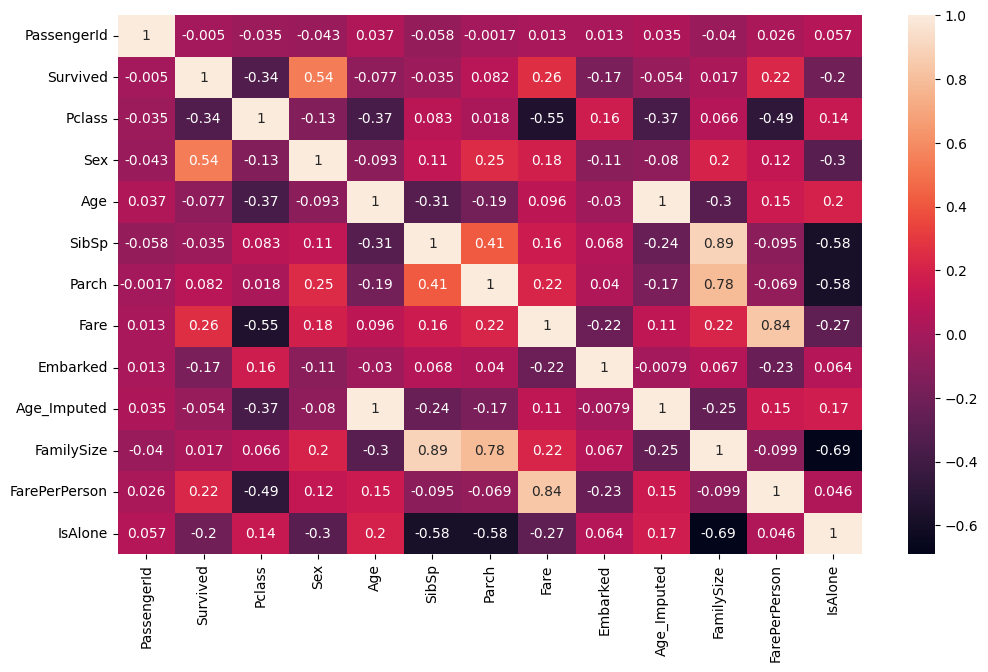

In [ ]:
plt.figure(figsize=(12,7))
sns.heatmap(train_data.select_dtypes(include = ['number']).corr(), annot=True,)
plt.show()

In [ ]:
train_data.isna().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
                  ..
Ticket_Cat_SWPP    0
Ticket_Cat_WC      0
Ticket_Cat_WEP     0
Ticket_Cat_XXX     0
IsAlone            0
Length: 61, dtype: int64

<h1>Drop data


In [ ]:
drop_cols = ['PassengerId', 'Cabin', 'Ticket', 'Name', 'Boy', 'Age', 'Fare', 'Age_Imputed']
for col in drop_cols:
    train_data.drop(columns=[col], inplace=True)
    test_data.drop(columns=[col], inplace=True)

In [ ]:
train_data.isna().sum()

Survived              0
Pclass                0
Sex                   0
SibSp                 0
Parch                 0
Embarked              0
WomanOrBoy            0
FamilySize            0
FarePerPerson         0
name_title_Master     0
name_title_Miss       0
name_title_Mr         0
name_title_Mrs        0
name_title_Other      0
Fare_Cat_cheap        0
Fare_Cat_Medium       0
Fare_Cat_Expensive    0
Age_Cat_so_young      0
Age_Cat_young         0
Age_Cat_teenager      0
Age_Cat_adult         0
Age_Cat_old           0
Ticket_Cat_A5         0
Ticket_Cat_AS         0
Ticket_Cat_C          0
Ticket_Cat_CA         0
Ticket_Cat_CASOTON    0
Ticket_Cat_FC         0
Ticket_Cat_FCC        0
Ticket_Cat_Fa         0
Ticket_Cat_LINE       0
Ticket_Cat_PC         0
Ticket_Cat_PP         0
Ticket_Cat_PPP        0
Ticket_Cat_SC         0
Ticket_Cat_SCA4       0
Ticket_Cat_SCAH       0
Ticket_Cat_SCOW       0
Ticket_Cat_SCPARIS    0
Ticket_Cat_SCParis    0
Ticket_Cat_SOC        0
Ticket_Cat_SOP  

In [ ]:
sum([1 for _ in train_data.columns])

53

In [ ]:
vs

NameError: name 'vs' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)

    print(f"{name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC AUC:  {roc_auc:.4f}")
    print("-" * 30)

Logistic Regression Results:
  Accuracy: 0.8492
  F1 Score: 0.7970
  ROC AUC:  0.8757
------------------------------
Random Forest Results:
  Accuracy: 0.7933
  F1 Score: 0.7376
  ROC AUC:  0.8260
------------------------------
XGBoost Results:
  Accuracy: 0.7989
  F1 Score: 0.7313
  ROC AUC:  0.8294
------------------------------


In [ ]:
best_model = LogisticRegression(random_state=42, max_iter=1000)
# best_model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200)
# best_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

y_val_pred = best_model.predict(X_val)

print("Actual values (first 5):")
print(y_val.head())

print("\nPredicted values (first 5):")
print(pd.Series(y_val_pred).head())

Actual values (first 5):
565    0
160    0
553    1
860    0
241    1
Name: Survived, dtype: int64

Predicted values (first 5):
0    0
1    0
2    0
3    0
4    1
dtype: int64


In [ ]:
# Orijinal test csv'sini tekrar yükle (PassengerId için)
test_data_orig = pd.read_csv("/kaggle/input/titanic/test.csv")

# 1. Lấy danh sách tên cột từ tập huấn luyện (X_train)
# Đây là danh sách các cột mà mô hình của bạn đã được fit (học).
# LƯU Ý: Phải sử dụng X_train (hoặc biến chứa các features đã dùng để fit mô hình)
feature_cols_at_fit = X_train.columns

# 2. Đồng bộ hóa tập test_data
# Đảm bảo test_data có số lượng cột, tên cột và thứ tự cột giống hệt X_train.
# Các cột thiếu (ví dụ: 'Cabin_Imputed_7.0') sẽ được thêm vào với giá trị 0.
test_data_aligned = test_data.reindex(columns=feature_cols_at_fit, fill_value=0)

# best_model ile test verisi üzerinde tahmin yap
test_preds = best_model.predict(test_data_aligned)

# Submission dataframe'i oluştur
submission = pd.DataFrame({
    "PassengerId": test_data_orig["PassengerId"],
    "Survived": test_preds
})

# CSV olarak kaydet (kaggle ortamında)
submission.to_csv("submission.csv", index=False)

print("Submission file 'submission.csv' created.")

Submission file 'submission.csv' created.
